## 1. Import Libraries

In [1]:
!pip install statsmodels

In [2]:
!pip install wordcloud

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import eda_helper_functions
from sklearn.ensemble import IsolationForest 

## 2. Read the Training Data

In [4]:
#use training data for everything and then reproduce those results on val data and test data to prevent data leakage/spoofing.
file_path = r"C:\Users\smrts\Desktop\flight-price-prediction AWS Sagemaker\data\train.csv"

train = pd.read_csv(file_path)
train

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price
0,Jet Airways,2019-03-21,Bangalore,New Delhi,08:55:00,19:10:00,615,1.0,In-flight meal not included,7832
1,Jet Airways,2019-03-27,Delhi,Cochin,17:30:00,04:25:00,655,1.0,In-flight meal not included,6540
2,GoAir,2019-03-09,Bangalore,New Delhi,11:40:00,14:35:00,175,0.0,No Info,7305
3,Air India,2019-06-12,Kolkata,Banglore,09:25:00,18:30:00,545,1.0,No Info,8366
4,Jet Airways,2019-03-12,Bangalore,New Delhi,22:55:00,07:40:00,525,1.0,In-flight meal not included,11087
...,...,...,...,...,...,...,...,...,...,...
6690,Jet Airways,2019-03-21,Delhi,Cochin,10:45:00,18:50:00,1925,2.0,No Info,11093
6691,Air India,2019-05-01,Kolkata,Banglore,09:25:00,18:30:00,545,1.0,No Info,8891
6692,Jet Airways,2019-06-01,Delhi,Cochin,14:00:00,19:00:00,300,1.0,In-flight meal not included,10262
6693,Air Asia,2019-06-24,Delhi,Cochin,07:55:00,13:25:00,330,1.0,No Info,6152


In [5]:
train.dtypes

airline                str
date_of_journey        str
source                 str
destination            str
dep_time               str
arrival_time           str
duration             int64
total_stops        float64
additional_info        str
price                int64
dtype: object

- update dtypes of columns 

In [6]:
train = train.assign(** {
    col: pd.to_datetime(train.loc[:, col], format= 'mixed')
    for col in ["date_of_journey", "dep_time", "arrival_time"]
})
train.dtypes

airline                       str
date_of_journey    datetime64[us]
source                        str
destination                   str
dep_time           datetime64[us]
arrival_time       datetime64[us]
duration                    int64
total_stops               float64
additional_info               str
price                       int64
dtype: object

In [7]:
train

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price
0,Jet Airways,2019-03-21,Bangalore,New Delhi,2026-06-22 08:55:00,2026-06-22 19:10:00,615,1.0,In-flight meal not included,7832
1,Jet Airways,2019-03-27,Delhi,Cochin,2026-06-22 17:30:00,2026-06-22 04:25:00,655,1.0,In-flight meal not included,6540
2,GoAir,2019-03-09,Bangalore,New Delhi,2026-06-22 11:40:00,2026-06-22 14:35:00,175,0.0,No Info,7305
3,Air India,2019-06-12,Kolkata,Banglore,2026-06-22 09:25:00,2026-06-22 18:30:00,545,1.0,No Info,8366
4,Jet Airways,2019-03-12,Bangalore,New Delhi,2026-06-22 22:55:00,2026-06-22 07:40:00,525,1.0,In-flight meal not included,11087
...,...,...,...,...,...,...,...,...,...,...
6690,Jet Airways,2019-03-21,Delhi,Cochin,2026-06-22 10:45:00,2026-06-22 18:50:00,1925,2.0,No Info,11093
6691,Air India,2019-05-01,Kolkata,Banglore,2026-06-22 09:25:00,2026-06-22 18:30:00,545,1.0,No Info,8891
6692,Jet Airways,2019-06-01,Delhi,Cochin,2026-06-22 14:00:00,2026-06-22 19:00:00,300,1.0,In-flight meal not included,10262
6693,Air Asia,2019-06-24,Delhi,Cochin,2026-06-22 07:55:00,2026-06-22 13:25:00,330,1.0,No Info,6152


## 3. High-Level Summary of Data

In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6695 entries, 0 to 6694
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   airline          6695 non-null   str           
 1   date_of_journey  6695 non-null   datetime64[us]
 2   source           6695 non-null   str           
 3   destination      6695 non-null   str           
 4   dep_time         6695 non-null   datetime64[us]
 5   arrival_time     6695 non-null   datetime64[us]
 6   duration         6695 non-null   int64         
 7   total_stops      6694 non-null   float64       
 8   additional_info  6695 non-null   str           
 9   price            6695 non-null   int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(4)
memory usage: 523.2 KB


In [9]:
train.describe(include= 'number')

,duration,total_stops,price
count,6695.000000,6694.000000,6695.000000
mean,633.489171,0.801464,9030.965646
std,503.006311,0.659737,4639.522857
min,75.000000,0.000000,1759.000000
25%,170.000000,0.000000,5224.000000
50%,510.000000,1.000000,8283.000000
75%,922.500000,1.000000,12373.000000
max,2860.000000,3.000000,62427.000000


- on an avg the duration of the flights is 630 minutes. 
- prices ranges upto 62k for very long-hour flights. 

In [10]:
(
    train
    .assign(total_stops = train["total_stops"].astype("string"))
    .describe(include = "string")
)

,airline,source,destination,total_stops,additional_info
count,6695,6695,6695,6694,6695
unique,12,5,6,4,7
top,Jet Airways,Delhi,Cochin,1.0,No Info
freq,2386,2730,2730,3580,5249


- 

## 4. High-Level Analysis of Missing Values

In [11]:
eda_helper_functions.missing_info(train)

,count,percentage
variable,,
total_stops,1,0.014937


In [12]:
train = train.dropna(subset=["total_stops"])

In [13]:
eda_helper_functions.missing_info(train)

,count,percentage
variable,,


In [14]:
train["total_stops"].isna().sum()

np.int64(0)

- there was 1 missing value in total_stops
- dropped that 1 row as dropping it'd have been negligible over the entire dataset

## 5. High Level Analysis of Outliers

In [15]:
forest = IsolationForest(n_estimators= 10, random_state= 42)

In [16]:
# using Isolation Forest
# creating new column for outlier and training and predicting
#using only numeric features except target feature ie price
#use query method to filter the df for outliers 
# outliers: if 1-> inlier(normal) and if -1 -> anomaly (outlier)
(
    train
    .assign(outlier = forest.fit_predict(train
                                        .drop(columns = "price")
                                        .select_dtypes(include= "number")))
  .query("outlier == -1")  
)

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price,outlier
5,Jet Airways,2019-04-21,Bangalore,Delhi,2026-06-22 18:55:00,2026-06-22 22:00:00,185,0.0,In-flight meal not included,4544,-1
7,Spicejet,2019-06-15,Mumbai,Hyderabad,2026-06-22 05:45:00,2026-06-22 07:15:00,90,0.0,No check-in baggage included,2647,-1
9,Jet Airways,2019-05-09,Delhi,Cochin,2026-06-22 23:05:00,2026-06-22 04:25:00,1760,2.0,No Info,15129,-1
10,Jet Airways,2019-06-12,Kolkata,Banglore,2026-06-22 14:05:00,2026-06-22 10:05:00,1200,1.0,No Info,13044,-1
12,Jet Airways,2019-06-24,Delhi,Cochin,2026-06-22 21:25:00,2026-06-22 19:00:00,1295,2.0,No Info,13292,-1
...,...,...,...,...,...,...,...,...,...,...,...
6687,Air India,2019-06-06,Kolkata,Banglore,2026-06-22 05:50:00,2026-06-22 08:55:00,1625,2.0,No Info,12723,-1
6688,Jet Airways,2019-06-15,Delhi,Cochin,2026-06-22 21:25:00,2026-06-22 12:35:00,910,2.0,In-flight meal not included,9905,-1
6689,Indigo,2019-03-03,Mumbai,Hyderabad,2026-06-22 09:10:00,2026-06-22 10:40:00,90,0.0,No Info,5755,-1
6690,Jet Airways,2019-03-21,Delhi,Cochin,2026-06-22 10:45:00,2026-06-22 18:50:00,1925,2.0,No Info,11093,-1


## 6. Pair Plots

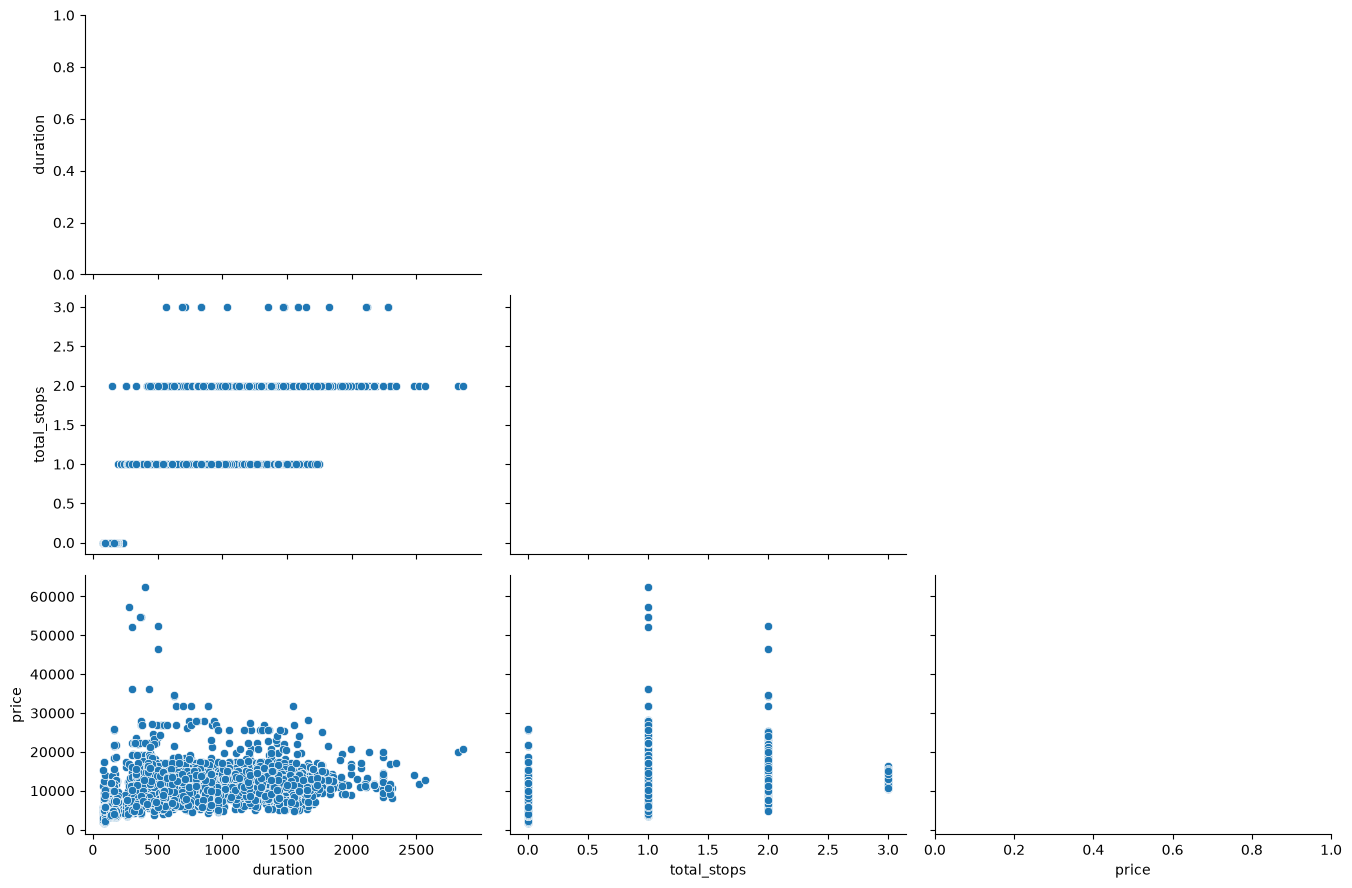

In [17]:
eda_helper_functions.pair_plots(train)

- used a feature called (corner = True) to show only the lower half of triangle for the pair plots are symmetric and the upper half would have had redundant data

## 7. Correlation Analysis

In [18]:
train.corr(method="spearman", numeric_only = True)

,duration,total_stops,price
duration,1.000000,0.822906,0.698000
total_stops,0.822906,1.000000,0.721034
price,0.698000,0.721034,1.000000


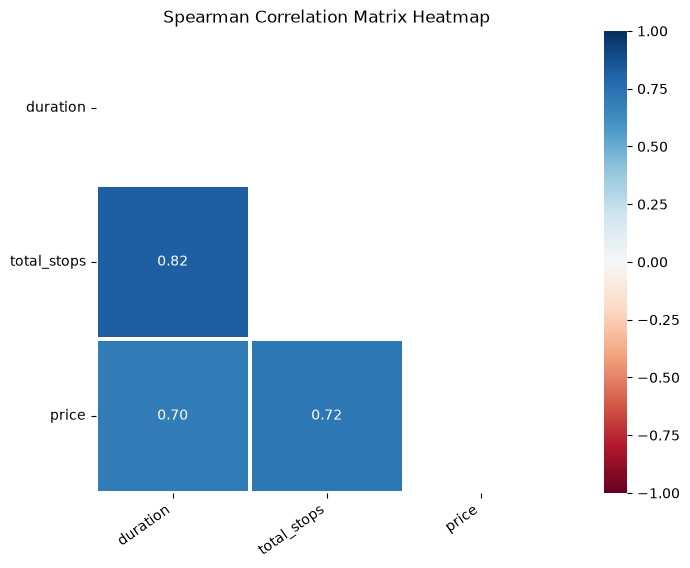

In [19]:
eda_helper_functions.correlation_heatmap(train)

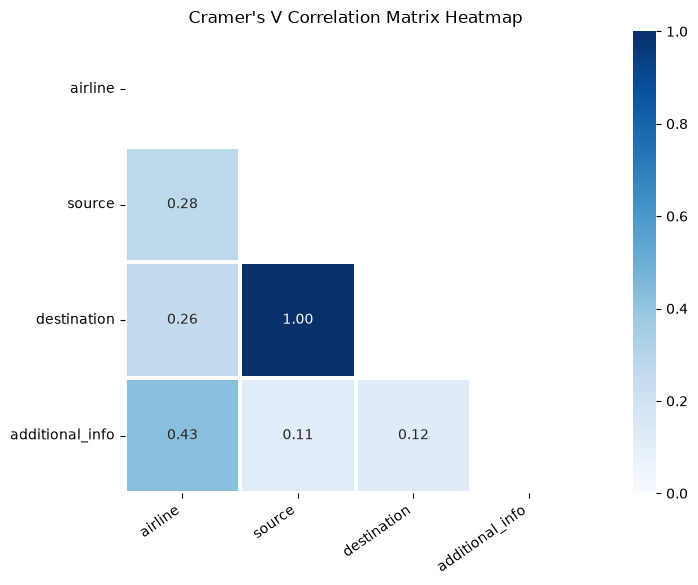

In [20]:
# categorical features heatmap
eda_helper_functions.cramersV_heatmap(train)

- for source and destination many values are same (overlap) thus its highest ie 1.
- create matrix then heatmap (triu: upper triangle)    

## 8. Detailed Analysis 

In [21]:
train.columns

Index(['airline', 'date_of_journey', 'source', 'destination', 'dep_time',
       'arrival_time', 'duration', 'total_stops', 'additional_info', 'price'],
      dtype='str')

In [22]:
train.airline

0       Jet Airways
1       Jet Airways
2             GoAir
3         Air India
4       Jet Airways
           ...     
6690    Jet Airways
6691      Air India
6692    Jet Airways
6693       Air Asia
6694      Air India
Name: airline, Length: 6694, dtype: str

In [23]:
eda_helper_functions.cat_summary(train, "airline")

0       Jet Airways
1       Jet Airways
2             GoAir
3         Air India
4       Jet Airways
           ...     
6690    Jet Airways
6691      Air India
6692    Jet Airways
6693       Air Asia
6694      Air India
Name: airline, Length: 6694, dtype: str

Data Type      : str
Cardinality    : 12 categories
Missing Data   : 0 rows (0.00 %)
Available Data : 6,694 / 6,694 rows


,
count,6694
unique,12
top,Jet Airways
freq,2386


,count,percentage
category,,
Jet Airways,2386,0.356439
Indigo,1296,0.193606
Air India,1075,0.160592
Multiple Carriers,730,0.109053
Spicejet,537,0.080221
Vistara,319,0.047655
Air Asia,211,0.031521
GoAir,125,0.018673
Multiple Carriers,6,0.000896


- cardinality: no of unique categories 

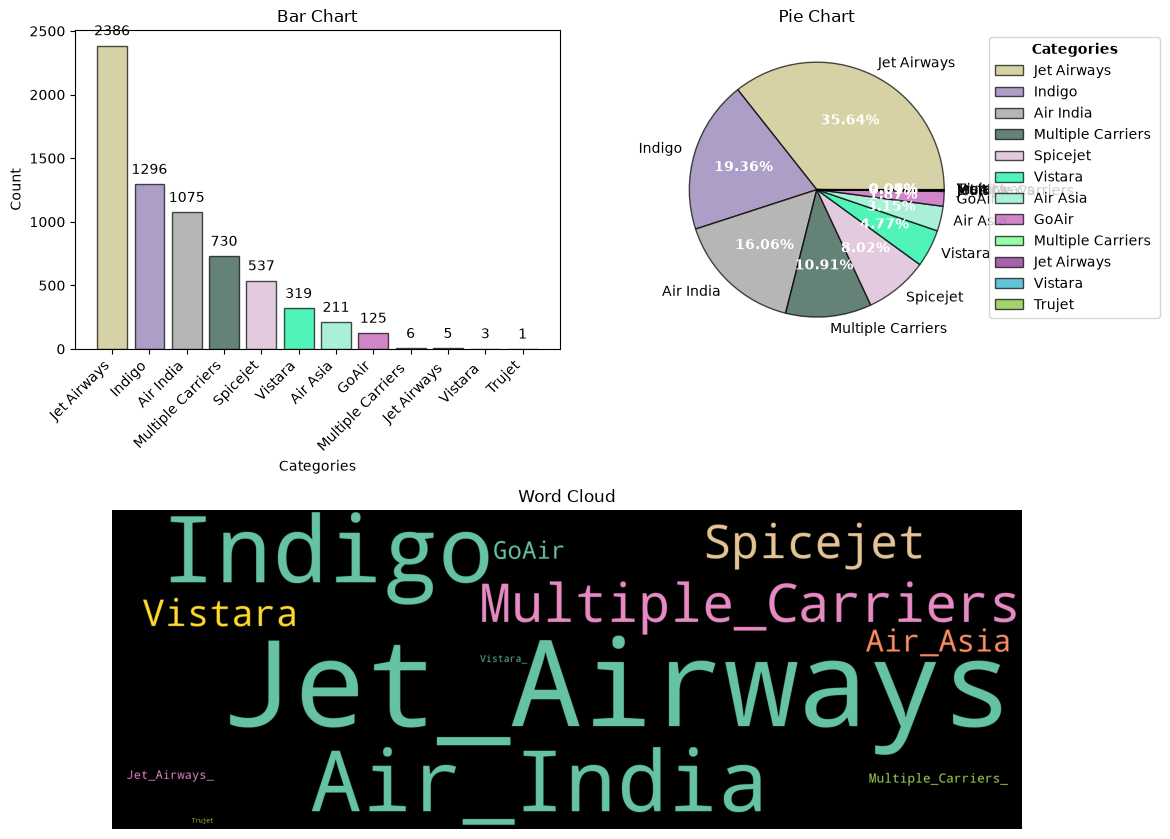

In [24]:
eda_helper_functions.cat_univar_plots(train, "airline")

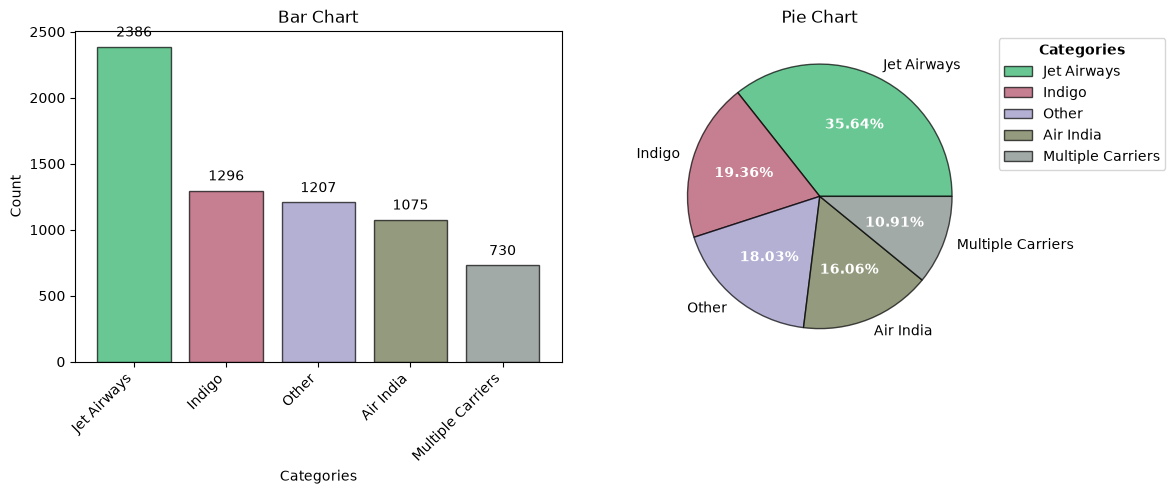

In [25]:
eda_helper_functions.cat_univar_plots(train, "airline",show_wordcloud = False, k = 4 )

- retain the most frequent categories and group the rare categories into one. [by using k=4]

- used Grid Spec to get this univariate plots
- Grid Spec is used for coordinates like (0,0) , (0,1) and then u want to merge the rest 2 coordinates into 1; (1,0) , (1,1) by slicing the y-axis from them ie (1...., 1....) so the last 2 coordinates merge into one. 

#### now for bivariate analysis of categorical columns 

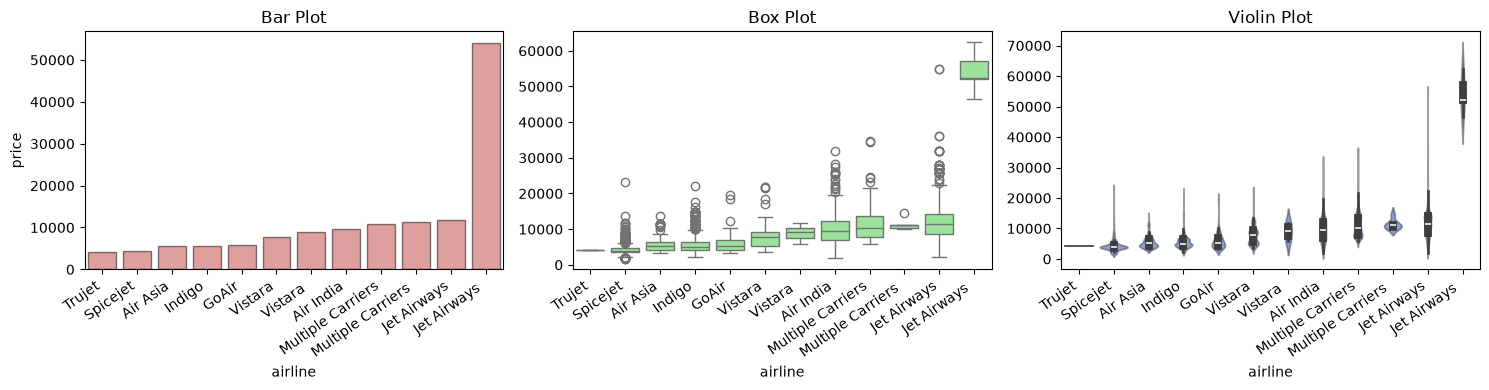

In [26]:
eda_helper_functions.num_cat_bivar_plots(
    data = train,
    num_var = "price",     # numerical variable
    cat_var = "airline"    # categorical variable
)

- airline is a good price predictor 

In [27]:
eda_helper_functions.num_cat_hyp_testing(train, "price", "airline") 

- Significance Level   : 5.0%
- Null Hypothesis      : The groups have similar population mean
- Alternate Hypothesis : The groups don't have similar population mean
- Test Statistic       : 447.16858995736334
- p-value              : 0.0
- Since p-value is less than 0.05, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: The variables price and airline are associated to each other


- Significance Level   : 5.0%
- Null Hypothesis      : The groups have similar population median
- Alternate Hypothesis : The groups don't have similar population median
- Test Statistic       : 3137.5099060146963
- p-value              : 0.0
- Since p-value is less than 0.05, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: The variables price and airline are associated to each other


- FacetGrid is helpful to make multivariate analysis

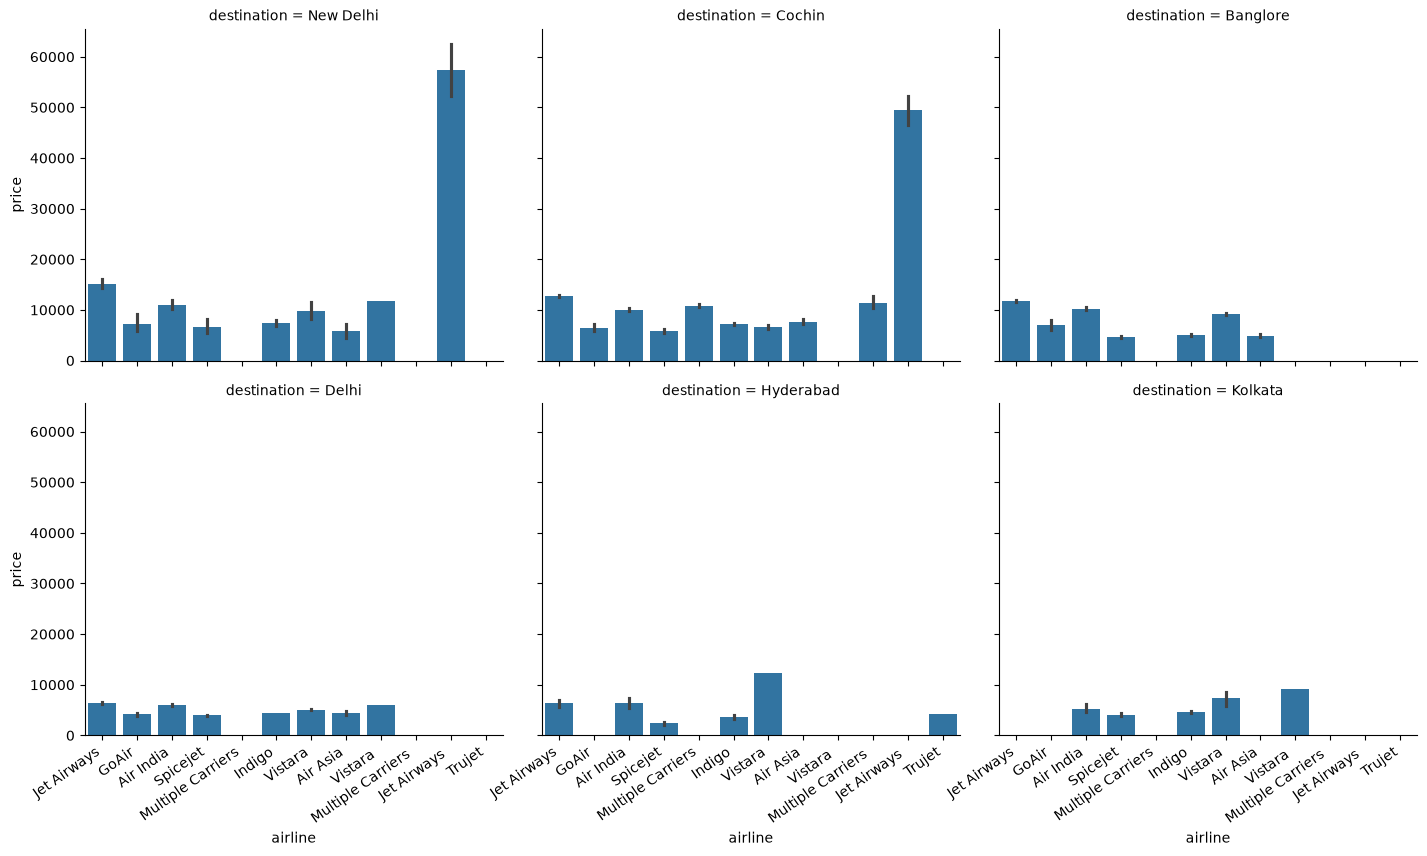

In [28]:
airline_grid = sns.FacetGrid(
    data = train,
    col = "destination",
    col_wrap = 3,
    height = 4,
    aspect = 1.2,
    sharey = True
)

airline_grid.map(sns.barplot, "airline", "price", order = train.airline.unique())
for ax in airline_grid.axes[3:]:
    eda_helper_functions.rotate_xlabels(ax)

### 8.2 date of journey

In [29]:
train.date_of_journey

0      2019-03-21
1      2019-03-27
2      2019-03-09
3      2019-06-12
4      2019-03-12
          ...    
6690   2019-03-21
6691   2019-05-01
6692   2019-06-01
6693   2019-06-24
6694   2019-03-01
Name: date_of_journey, Length: 6694, dtype: datetime64[us]

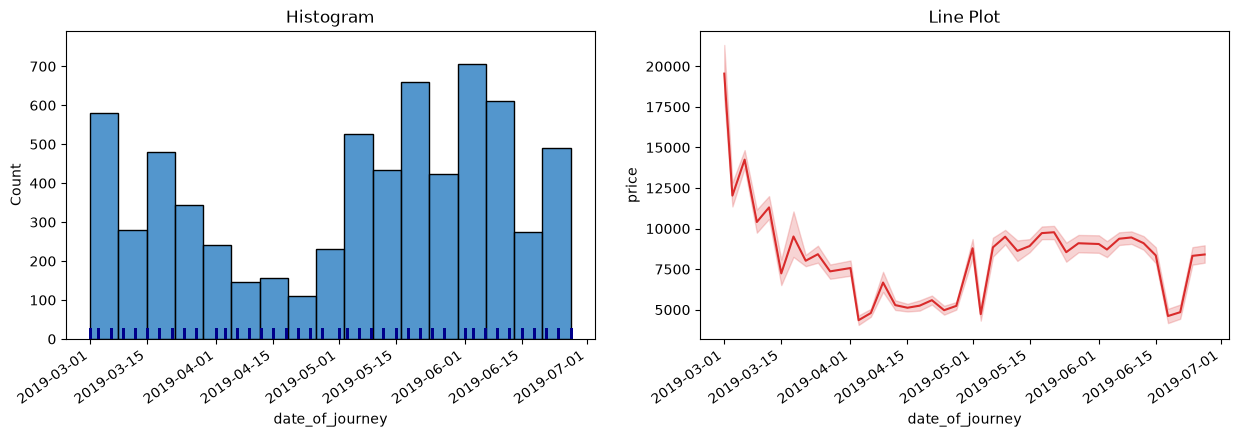

In [30]:
eda_helper_functions.dt_univar_plots(
    data = train,
    var = "date_of_journey",
    target = "price"
)

- the summer months are the busy months typically May and June
- the prices also decrease from March to May but then rise and are mostly same for June (in line plot)
- the dark blue small bars represent data points in histogram 

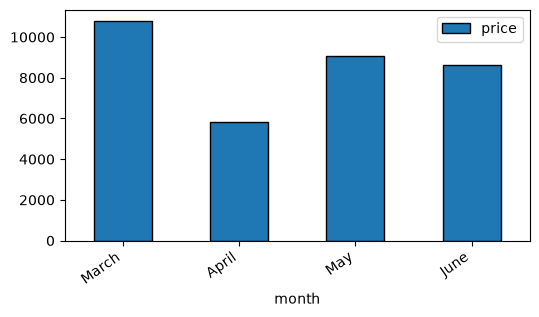

In [31]:
(
    train
    .groupby(pd.Grouper(key = "date_of_journey", freq = "ME"))
    .price.mean()
    .to_frame()
    .set_axis(["March", "April", "May", "June"], axis = 0)
    .rename_axis(index = "month")
    .plot(
        kind = "bar",
        figsize = (6,3),
        edgecolor = "black"
    )
)

ax = plt.gca()
eda_helper_functions.rotate_xlabels(ax)

- groups every individual value 
- to make it group month wise:
want to segregate date-time column inside pandas use pd.Grouper
- and then convert to df (apply to frame to 2 series and get df)
- setting axis: make axis 0 ie set index = months
- if u get graph/plot that means there is an axis, to acess that axis use : plt.gca()
- plt.gca() : gca stands for get current axis 

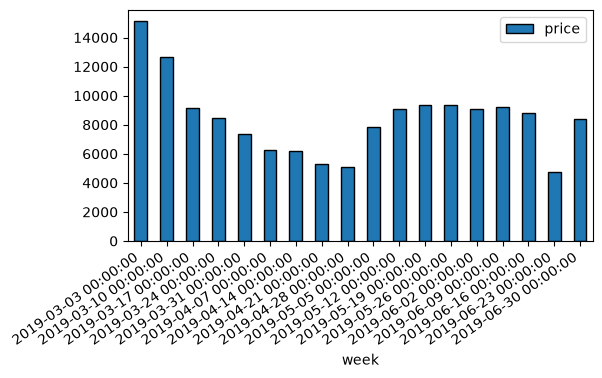

In [32]:
#weekly analysis
(
    train
    .groupby(pd.Grouper(key = "date_of_journey", freq = "W"))
    .price.mean()
    .to_frame()
    .rename_axis(index = "week")
    .plot(
        kind = "bar",
        figsize = (6,3),
        edgecolor = "black"
    )
)

ax = plt.gca()
eda_helper_functions.rotate_xlabels(ax)

## Multivariate Analysis
avg price of airlines from each source, monthly-wise

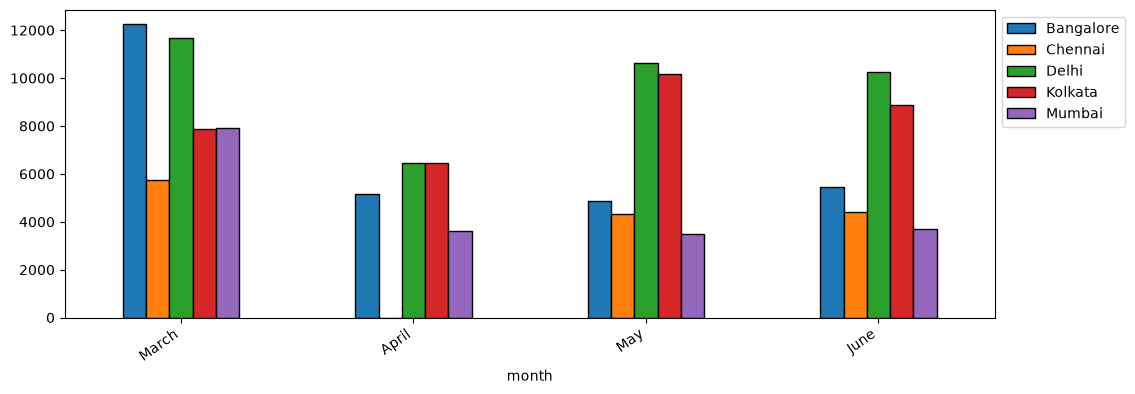

In [33]:
(
    train
    .groupby([pd.Grouper(key = "date_of_journey", freq = "ME"), "source"])
    .price.mean()
    .unstack(fill_value = 0)
    .set_axis(["March", "April", "May", "June"], axis = 0)
    .rename_axis(index = "month")
    .plot(
        kind = "bar",
        figsize = (12,4),
        edgecolor = "black"
        
    )
)
ax = plt.gca()
ax.legend(
    loc = "upper left",
    bbox_to_anchor = (1,1)
)
eda_helper_functions.rotate_xlabels(ax)

- to grp a time series and cat data, create a list and apply Groupby
- move 1 axis to a column : to get a table use unstack()
- this results in : month -> index and source -> columns
- use (fill_value = 0) attribute to fill missing values [NaN]
- the legend is coming inside the plot move it outside 

### 8.3 dep_time

In [34]:
train.dep_time

0      2026-06-22 08:55:00
1      2026-06-22 17:30:00
2      2026-06-22 11:40:00
3      2026-06-22 09:25:00
4      2026-06-22 22:55:00
               ...        
6690   2026-06-22 10:45:00
6691   2026-06-22 09:25:00
6692   2026-06-22 14:00:00
6693   2026-06-22 07:55:00
6694   2026-06-22 11:50:00
Name: dep_time, Length: 6694, dtype: datetime64[us]

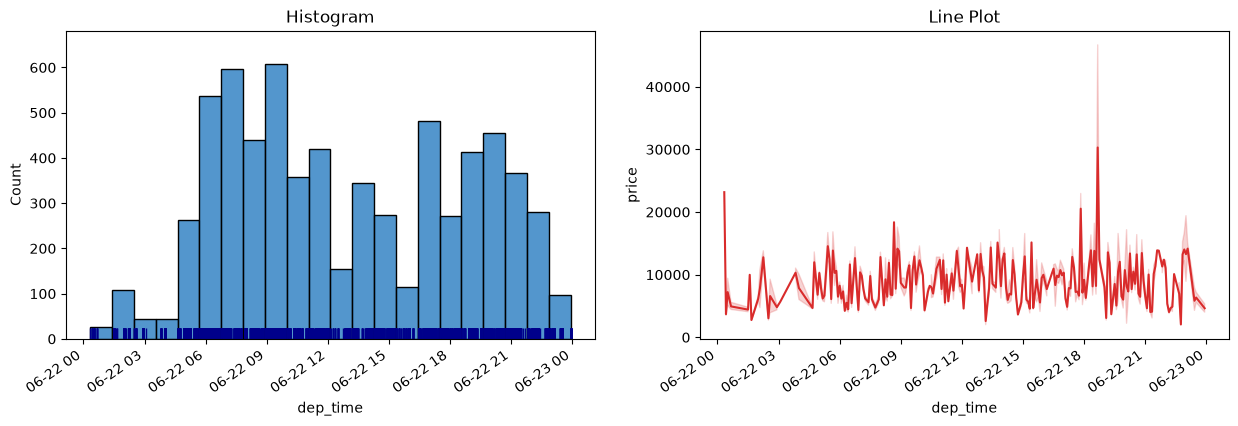

In [35]:
eda_helper_functions.dt_univar_plots(train, "dep_time", "price")

- flights are mostly booked from 7 am - 12pm and then throughout the day but eve 6pm to 9pm again bookings and morn 12am to 7am few bookings
- but the graphs are not easy to interpret
- since this contains only hours info (and the trends also vary with price and frequency of booking flights)
- convert this into part of the day (mor, eve, noon)

In [36]:
(
    train
    .dep_time
    .dt.hour # inbuilt in pandas (like string access - str.len() same like that)
    .pipe(lambda ser : pd.Series(np.select( [ser.between(4,12, inclusive = "left"), # value >= 4 and < 12 (incluse = left)
                                  ser.between(12,16, inclusive = "left"),
                                  ser.between(16,20, inclusive = "left")], 
                                  ["morning",
                                  "afternoon",
                                  "evening"],
                                  default = "night"))) #if calling pipe on a series, pipe will accept a func whose i/p is also a series
)

0         morning
1         evening
2         morning
3         morning
4           night
          ...    
6689      morning
6690      morning
6691    afternoon
6692      morning
6693      morning
Length: 6694, dtype: str

convert each hour to category
lambda to capture current state of the values, o/p came same so we use np.select ()
- np.select(
    takes 3 values : 1st list [] -> give ur conditions
    2nd list []
and a default value (for now abc )
- can use apply method as well but only use it as last option bcz it works value-by-value
- whereas np.select would work as vectorisation (by comparing whole series)

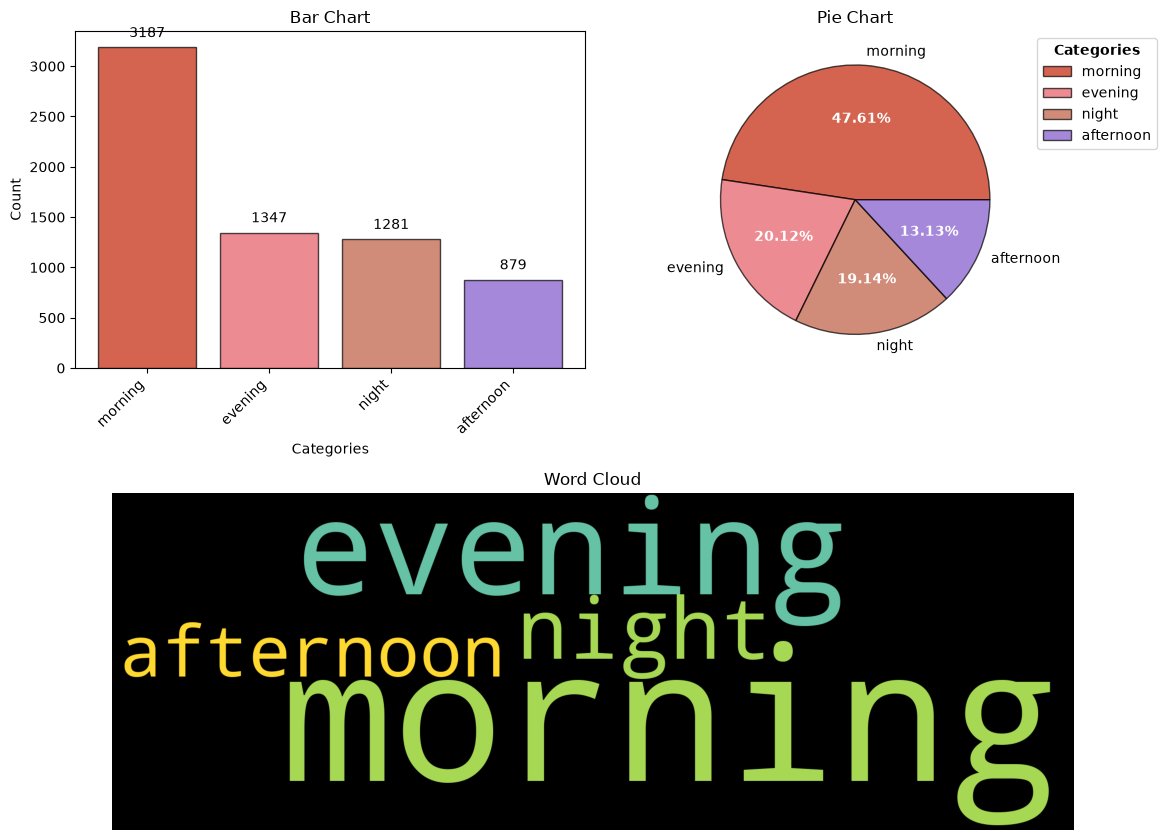

In [37]:
(
    train
    .assign(dep_time = lambda df_:( # assign is used to either create a new column or update an existing one
        np.select([df_.dep_time.dt.hour.between(4,12, inclusive = "left"), # value >= 4 and < 12 (incluse = left)
                   df_.dep_time.dt.hour.between(12,16, inclusive = "left"),
                   df_.dep_time.dt.hour.between(16,20, inclusive = "left")], 
                   ["morning", "afternoon", "evening"],
                   default = "night")
       )
    ) #either create a new column or update an existing one
    .pipe(eda_helper_functions.cat_univar_plots, "dep_time")
)

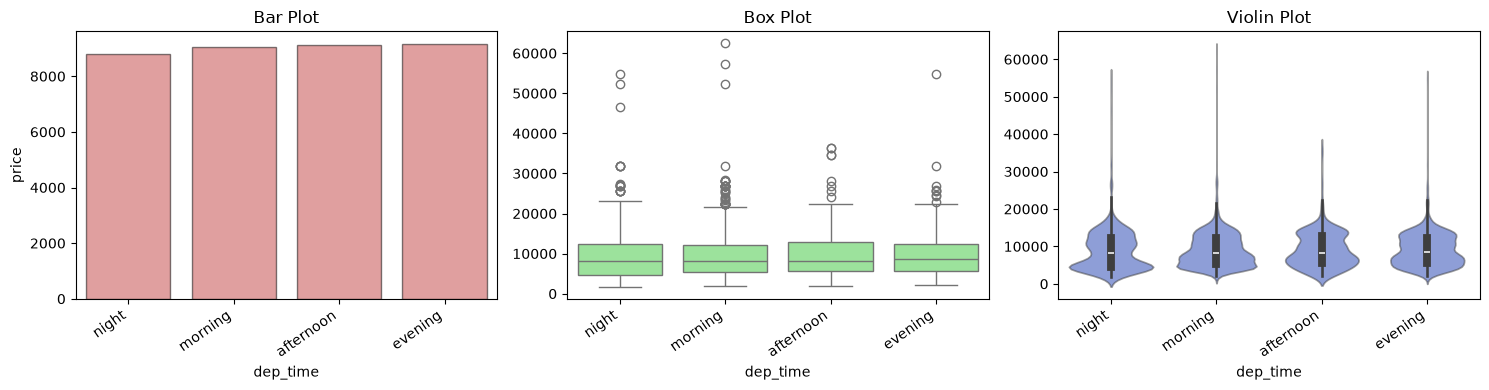

In [38]:
(
    train
    .assign(dep_time = lambda df_:( # assign is used to either create a new column or update an existing one
        np.select([df_.dep_time.dt.hour.between(4,12, inclusive = "left"), # value >= 4 and < 12 (incluse = left)
                   df_.dep_time.dt.hour.between(12,16, inclusive = "left"),
                   df_.dep_time.dt.hour.between(16,20, inclusive = "left")], 
                   ["morning", "afternoon", "evening"],
                   default = "night")
       )
    )
    .pipe(eda_helper_functions.num_cat_bivar_plots, "price", "dep_time")
)

### 8.4 duration 

In [39]:
train.duration

0        615
1        655
2        175
3        545
4        525
        ... 
6690    1925
6691     545
6692     300
6693     330
6694    1265
Name: duration, Length: 6694, dtype: int64

In [40]:
eda_helper_functions.num_summary(train, "duration")

0        615
1        655
2        175
3        545
4        525
        ... 
6690    1925
6691     545
6692     300
6693     330
6694    1265
Name: duration, Length: 6694, dtype: int64

Data Type      : int64
Missing Data   : 0 rows (0.00 %)
Available Data : 6,694 / 6,694 rows


,value
percentile,
0,75.00
5,90.00
10,145.00
25,170.00
50,510.00
75,920.00
90,1440.00
95,1601.75
99,1855.00


,value
mean,633.371676
trimmed mean (5%),599.575174
trimmed mean (10%),570.895258
median,510.000000


,value
var,252960.712875
std,502.951999
IQR,750.000000
mad,340.000000
coef_variance,0.794087


,value
skewness,0.894131
kurtosis,-0.052204


Significance Level   : 0.05
Null Hypothesis      : The data is normally distributed
Alternate Hypothesis : The data is not normally distributed
p-value              : 7.367044778597017e-57
Test Statistic       : 0.886539636636061
- Since p-value is less than alpha (0.05), we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: We conclude that the data sample is not normally distributed


Significance Level   : 0.05
Null Hypothesis      : The data is normally distributed
Alternate Hypothesis : The data is not normally distributed
Critical Value       : 0.752
Test Statistic       : 248.45769626661695
- Since the Test-statistic is greater than Critical Value, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: We conclude that the data sample is not normally distributed


- for percentiles:
0 -> shortest flight is 75 minutes
10 %ile -> 10% of the flights have duration less than 145 minutes in duration. 

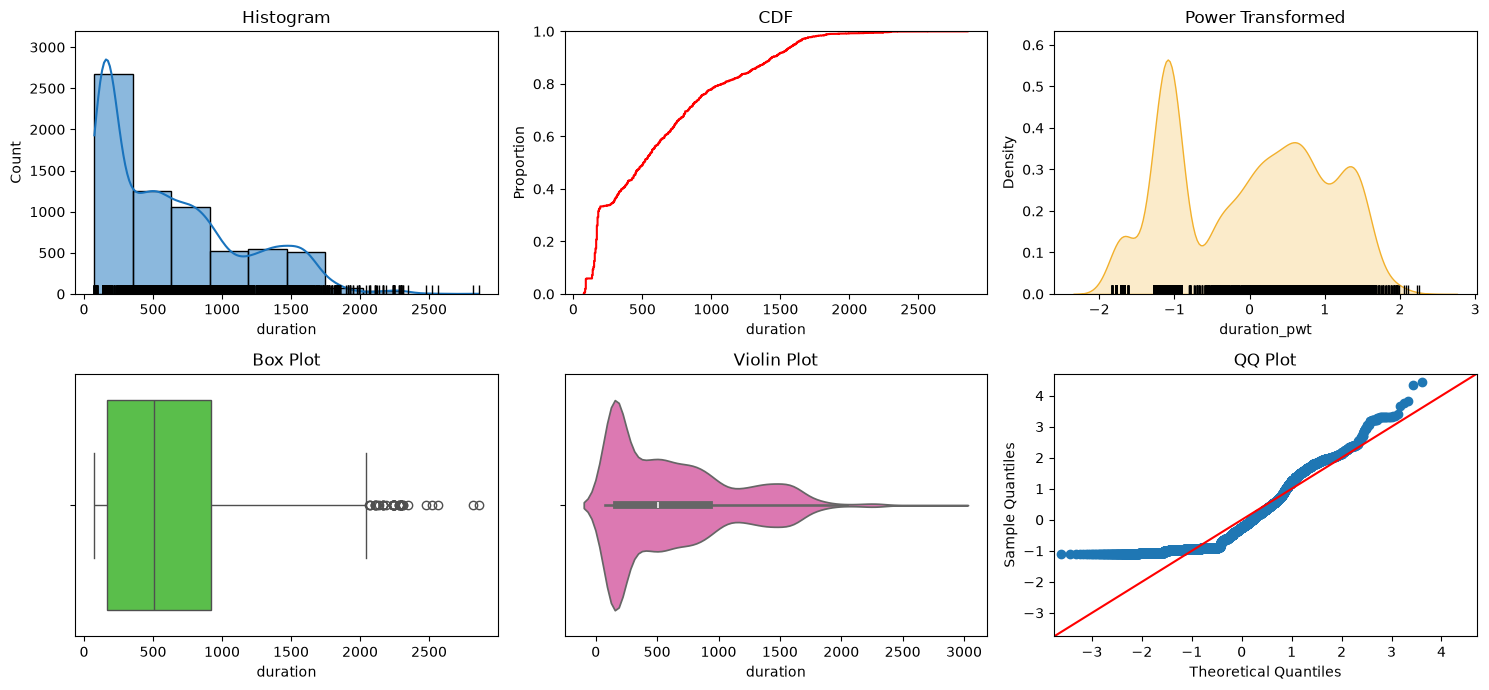

In [41]:
eda_helper_functions.num_univar_plots(train, "duration")

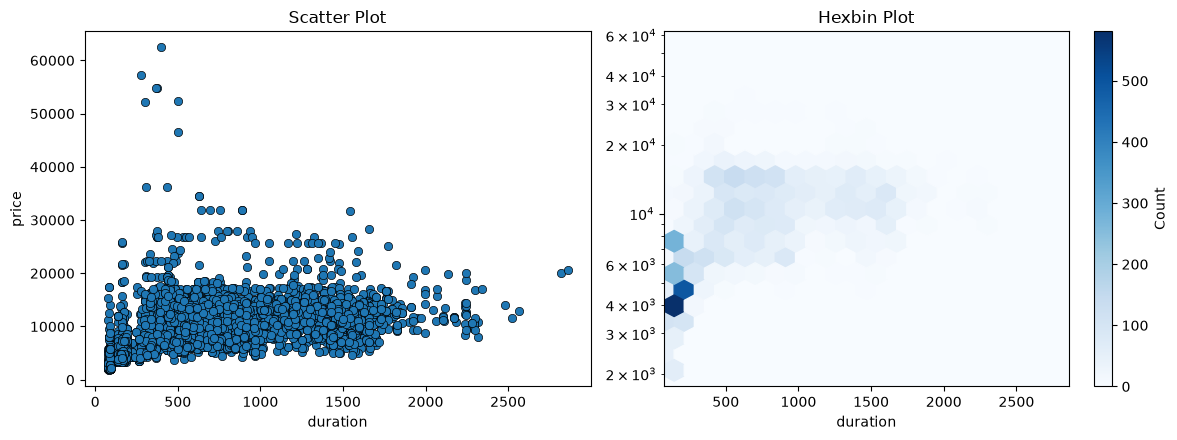

In [42]:
eda_helper_functions.num_bivar_plots(
    train, 
    "duration", 
    "price",
    hexbin_kwargs = dict(
        yscale = "log",
        gridsize = 20,
        cmap = "Blues"
    )
)

In [43]:
eda_helper_functions.num_num_hyp_testing(train, "duration", "price")

- Significance Level   : 5.0%
- Null Hypothesis      : The samples are uncorrelated
- Alternate Hypothesis : The samples are correlated
- Test Statistic       : 0.5091878071906604
- p-value              : 0.0
- Since p-value is less than 0.05, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: The variables duration and price are correlated


- Significance Level   : 5.0%
- Null Hypothesis      : The samples are uncorrelated
- Alternate Hypothesis : The samples are correlated
- Test Statistic       : 0.6980000420004596
- p-value              : 0.0
- Since p-value is less than 0.05, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: The variables duration and price are correlated


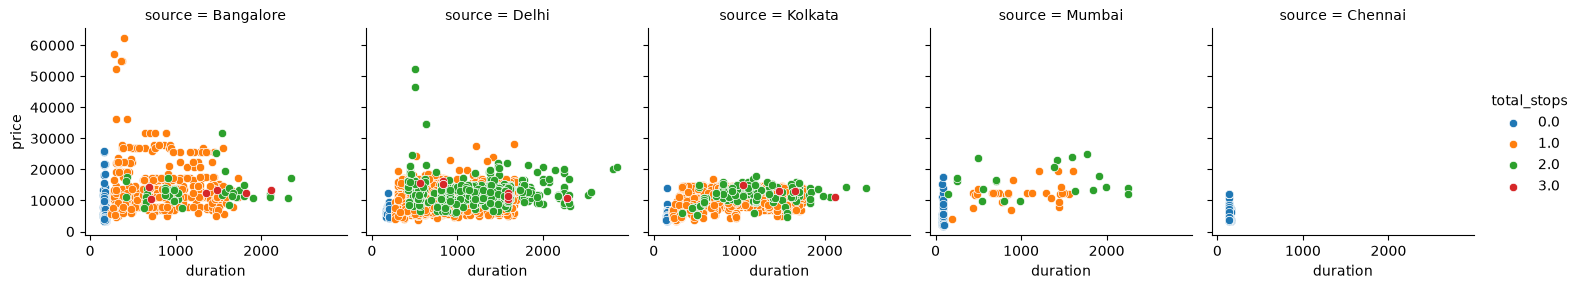

In [44]:
duration_grid = sns.FacetGrid(
    data = train,
    col = "source",
    hue = "total_stops",
    sharey = True
)

duration_grid.map(sns.scatterplot, "duration", "price")
duration_grid.add_legend()

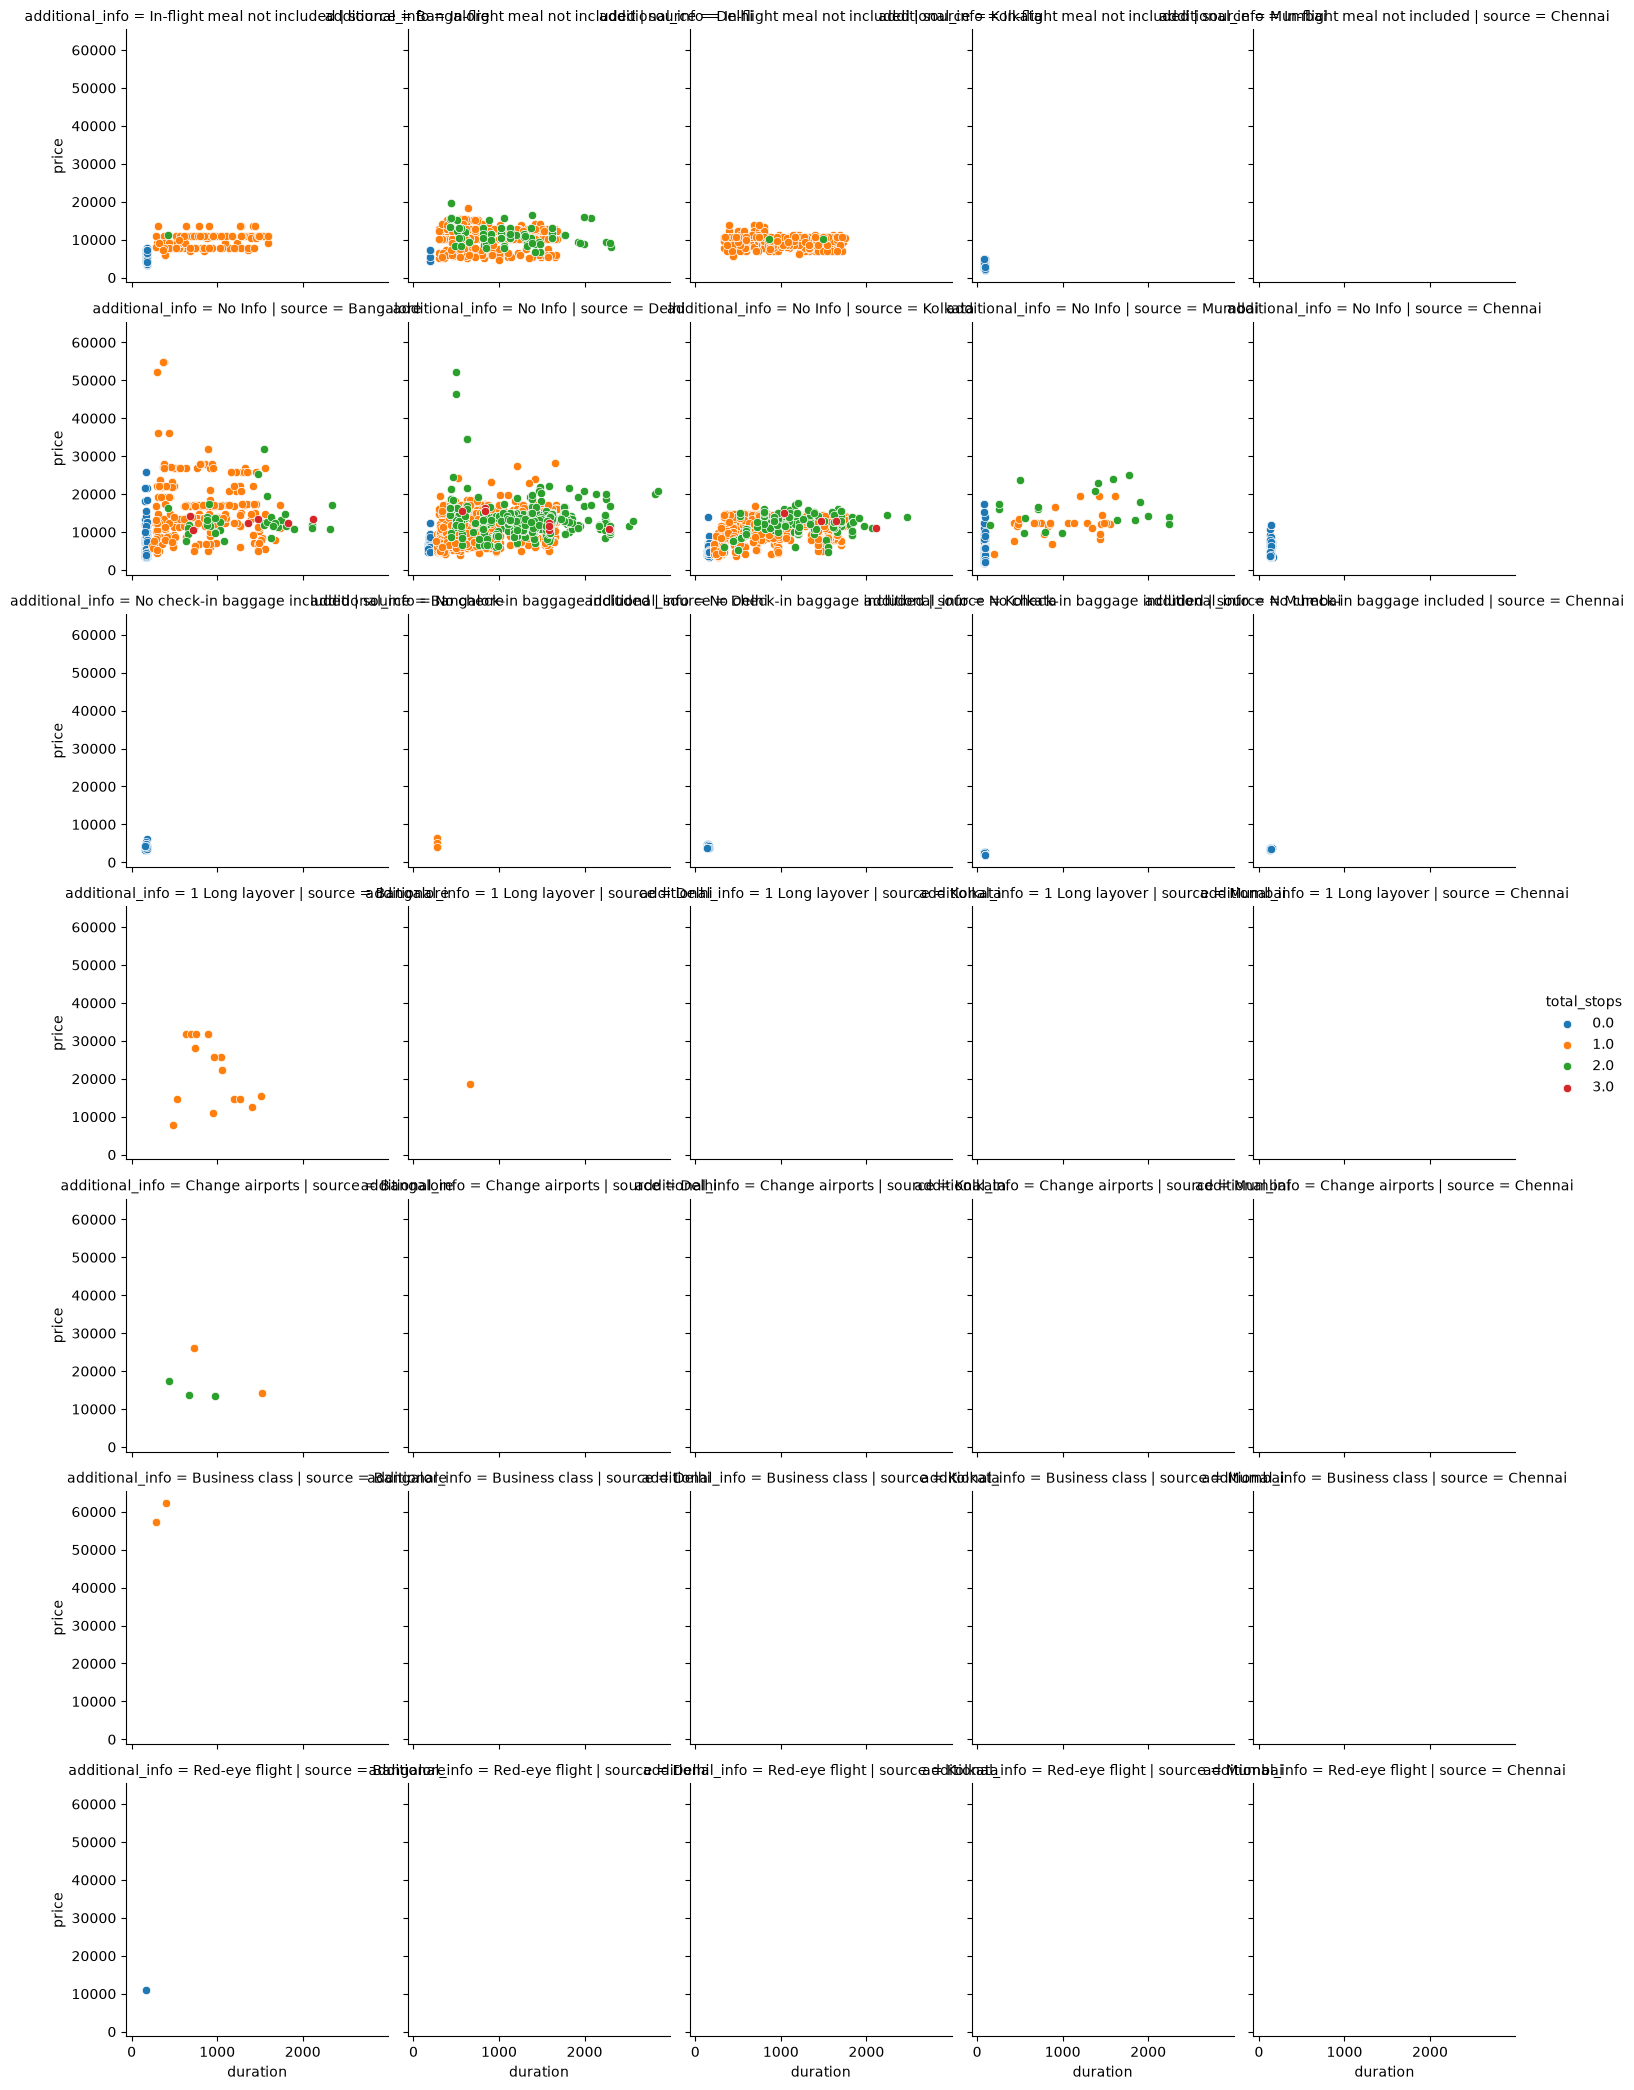

In [45]:
#5D plot
duration_grid = sns.FacetGrid(
    data = train,
    col = "source",
    row = "additional_info", 
    hue = "total_stops",
    sharey = True
)

duration_grid.map(sns.scatterplot, "duration", "price")
duration_grid.add_legend()

### 9. Automated EDA 

In [46]:
eda_helper_functions.get_iqr_outliers(train, "duration")

Lower Limit : -955.0
Upper Limit : 2045.0


,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price
3690,Air India,2019-05-01,Kolkata,Banglore,2026-06-22 05:50:00,2026-06-22 16:15:00,2065,2.0,No Info,10991
3225,Jet Airways,2019-03-06,Delhi,Cochin,2026-06-22 17:55:00,2026-06-22 04:25:00,2070,2.0,In-flight meal not included,15812
6079,Jet Airways,2019-03-06,Delhi,Cochin,2026-06-22 17:55:00,2026-06-22 04:25:00,2070,2.0,No Info,17072
1517,Air India,2019-03-03,Bangalore,New Delhi,2026-06-22 11:05:00,2026-06-22 22:10:00,2105,2.0,No Info,11948
4589,Air India,2019-03-18,Bangalore,New Delhi,2026-06-22 11:05:00,2026-06-22 22:10:00,2105,2.0,No Info,11161
2990,Air India,2019-03-03,Bangalore,New Delhi,2026-06-22 11:05:00,2026-06-22 22:10:00,2105,2.0,No Info,11791
2916,Air India,2019-05-12,Kolkata,Banglore,2026-06-22 12:00:00,2026-06-22 23:15:00,2115,3.0,No Info,10991
2170,Air India,2019-03-12,Bangalore,New Delhi,2026-06-22 06:45:00,2026-06-22 18:05:00,2120,3.0,No Info,13387
1105,Jet Airways,2019-03-06,Delhi,Cochin,2026-06-22 16:50:00,2026-06-22 04:25:00,2135,2.0,No Info,19907
3091,Air India,2019-03-03,Delhi,Cochin,2026-06-22 07:05:00,2026-06-22 19:15:00,2170,2.0,No Info,11762
